# NB03 — Exploratory Data Analysis & Comparative MX vs US
## YouTube Trending: ¿Son los mismos patrones en México y Estados Unidos?

---

**Objetivo de este notebook:**  
Explorar los patrones de viralidad y durabilidad en trending, con énfasis en las **diferencias entre MX y US**. Cada visualización responde una pregunta de negocio concreta.

**Preguntas clave:**
1. ¿Qué categorías generan videos más duraderos en trending?
2. ¿Existe un horario/día óptimo de publicación?
3. ¿El engagement del día 1 predice la durabilidad?
4. ¿Qué canales dominan el trending por región?
5. ¿Son los mercados estructuralmente distintos o similares?

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11
})
PALETTE = {'MX': '#E53935', 'US': '#1E88E5'}
DATA_PATH = '../data/'

mx = pd.read_parquet(f'{DATA_PATH}processed/mx_model.parquet')
us = pd.read_parquet(f'{DATA_PATH}processed/us_model.parquet')
combined = pd.read_parquet(f'{DATA_PATH}processed/combined_model.parquet')

print(f'MX: {len(mx):,} videos | US: {len(us):,} videos | Combined: {len(combined):,}')

MX: 32,442 videos | US: 47,142 videos | Combined: 79,584


## 2. Target Overview: MX vs US Distribution

Partimos del hallazgo central de NB02: los videos en MX trendan ~60% más días que en US.

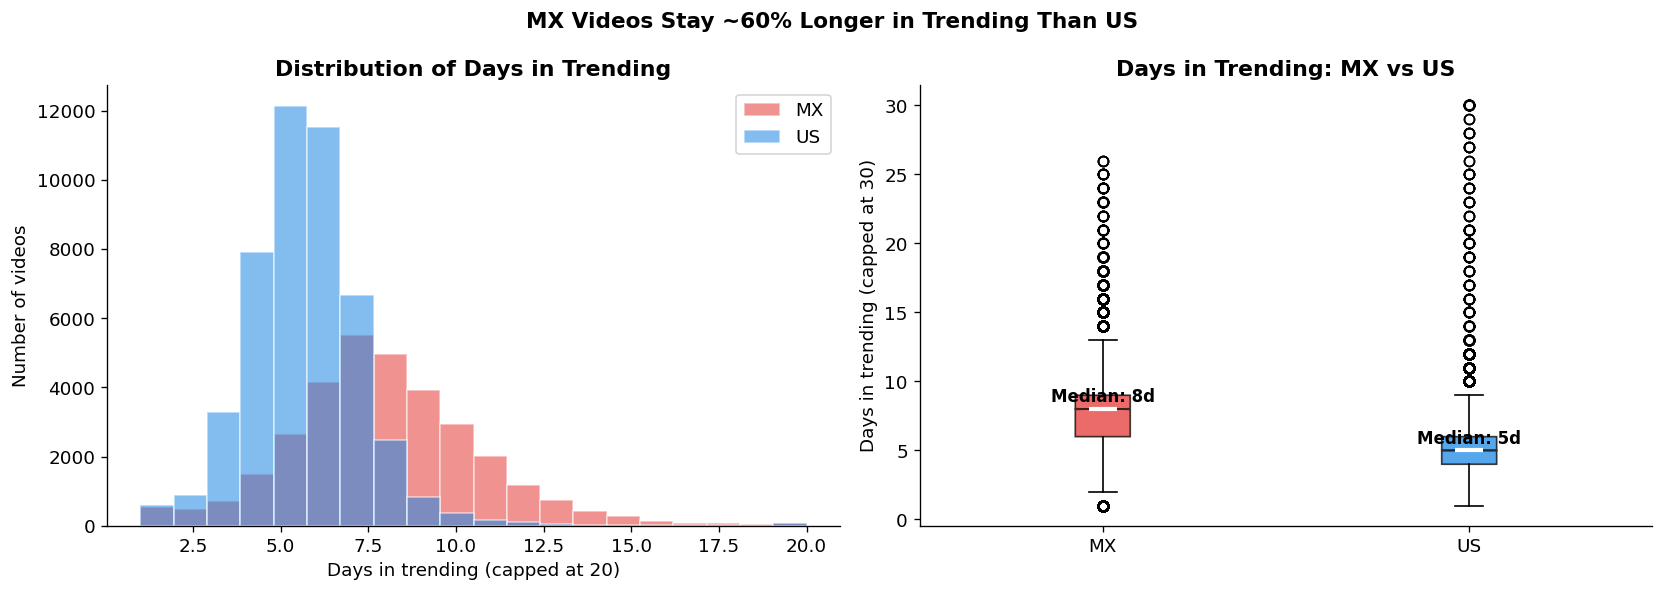

,MX,US
Metric,,
Mean,7.8,5.5
Median,8.0,5.0
Std,2.9,1.9
P75,9.0,6.0
P90,11.0,7.0
P95,13.0,8.0
Max,26.0,37.0


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histograms
ax = axes[0]
for name, df in [('MX', mx), ('US', us)]:
    ax.hist(df['days_in_trending'].clip(upper=20), bins=20,
            alpha=0.55, color=PALETTE[name], label=name, edgecolor='white')
ax.set_xlabel('Days in trending (capped at 20)')
ax.set_ylabel('Number of videos')
ax.set_title('Distribution of Days in Trending', fontweight='bold')
ax.legend()

# Right: boxplot comparison
ax = axes[1]
data_box = [
    mx['days_in_trending'].clip(upper=30).values,
    us['days_in_trending'].clip(upper=30).values
]
bp = ax.boxplot(data_box, patch_artist=True, notch=True,
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], ['#E53935', '#1E88E5']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticks([1, 2])
ax.set_xticklabels(['MX', 'US'])
ax.set_ylabel('Days in trending (capped at 30)')
ax.set_title('Days in Trending: MX vs US', fontweight='bold')

# Annotate medians
for i, (name, df) in enumerate(zip(['MX','US'],[mx, us]), 1):
    med = df['days_in_trending'].median()
    ax.text(i, med + 0.5, f'Median: {med:.0f}d', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('MX Videos Stay ~60% Longer in Trending Than US', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_07_target_mx_vs_us.png', bbox_inches='tight')
plt.show()

# Summary table
summary = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std', 'P75', 'P90', 'P95', 'Max'],
    'MX': [
        mx['days_in_trending'].mean().round(1),
        mx['days_in_trending'].median(),
        mx['days_in_trending'].std().round(1),
        mx['days_in_trending'].quantile(.75),
        mx['days_in_trending'].quantile(.90),
        mx['days_in_trending'].quantile(.95),
        mx['days_in_trending'].max()
    ],
    'US': [
        us['days_in_trending'].mean().round(1),
        us['days_in_trending'].median(),
        us['days_in_trending'].std().round(1),
        us['days_in_trending'].quantile(.75),
        us['days_in_trending'].quantile(.90),
        us['days_in_trending'].quantile(.95),
        us['days_in_trending'].max()
    ]
})
display(summary.set_index('Metric').style.format('{:.1f}').background_gradient(cmap='Blues', axis=1))

**Interpretación:**  
La diferencia entre mercados es estructural y estadísticamente evidente. Los videos en MX tienen una mediana de ~8 días en trending vs ~5 días en US. Esto puede explicarse por **menor volumen de creadores competidores en MX** (32k videos únicos vs 47k en US), lo que permite que cada video permanezca más tiempo antes de ser desplazado. En US, la mayor densidad de creadores genera mayor rotación.

## 3. Days in Trending by Category

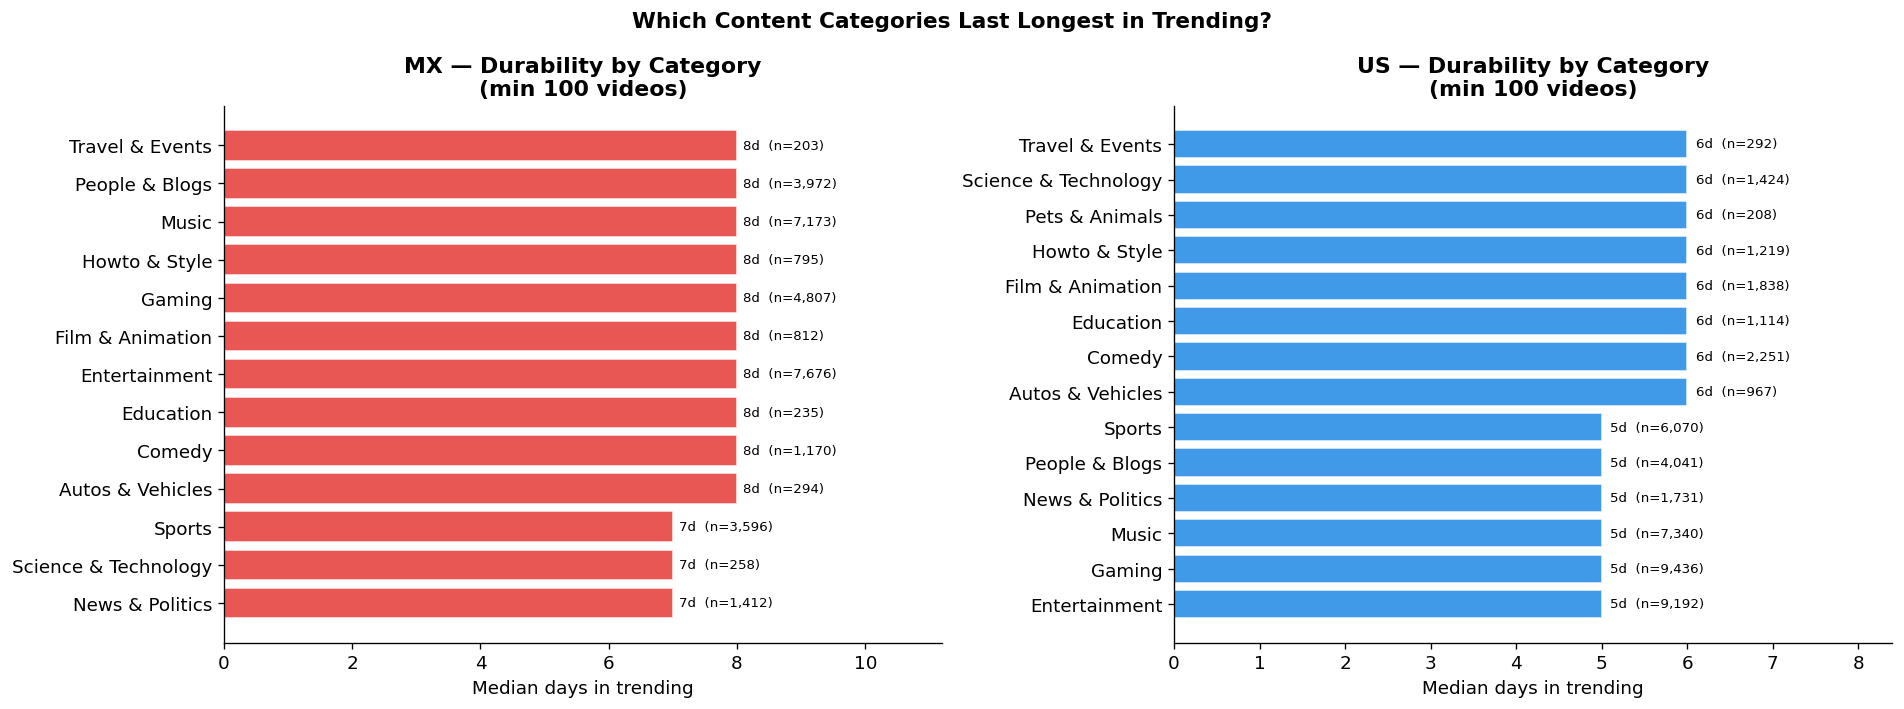

In [3]:
# Filter to categories with enough data
MIN_VIDEOS = 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, df) in zip(axes, [('MX', mx), ('US', us)]):
    cat_stats = (df.groupby('category_name')['days_in_trending']
                   .agg(['median', 'mean', 'count'])
                   .query('count >= @MIN_VIDEOS')
                   .sort_values('median', ascending=True))

    bars = ax.barh(cat_stats.index, cat_stats['median'],
                   color=PALETTE[name], alpha=0.85, edgecolor='white')
    ax.set_xlabel('Median days in trending')
    ax.set_title(f'{name} — Durability by Category\n(min {MIN_VIDEOS} videos)', fontweight='bold')

    for bar, (idx, row) in zip(bars, cat_stats.iterrows()):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f"{row['median']:.0f}d  (n={int(row['count']):,})",
                va='center', fontsize=8)
    ax.set_xlim(0, cat_stats['median'].max() * 1.4)

plt.suptitle('Which Content Categories Last Longest in Trending?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_08_category_durability.png', bbox_inches='tight')
plt.show()

**Interpretación:**  
La categoría **Music** tiende a tener la mayor durabilidad en trending en ambos mercados — los videos musicales son consumidos repetidamente y mantienen relevancia durante semanas. **Gaming** y **Entertainment** muestran alta rotación (menor duración) porque dependen de eventos y tendencias actuales. **News & Politics** tiene alta variabilidad: algunos eventos generan viralidad sostenida mientras otros son efímeros. Esta segmentación es un hallazgo de negocio relevante para estrategas de contenido.

## 4. Timing: Publish Hour & Day of Week vs Durability

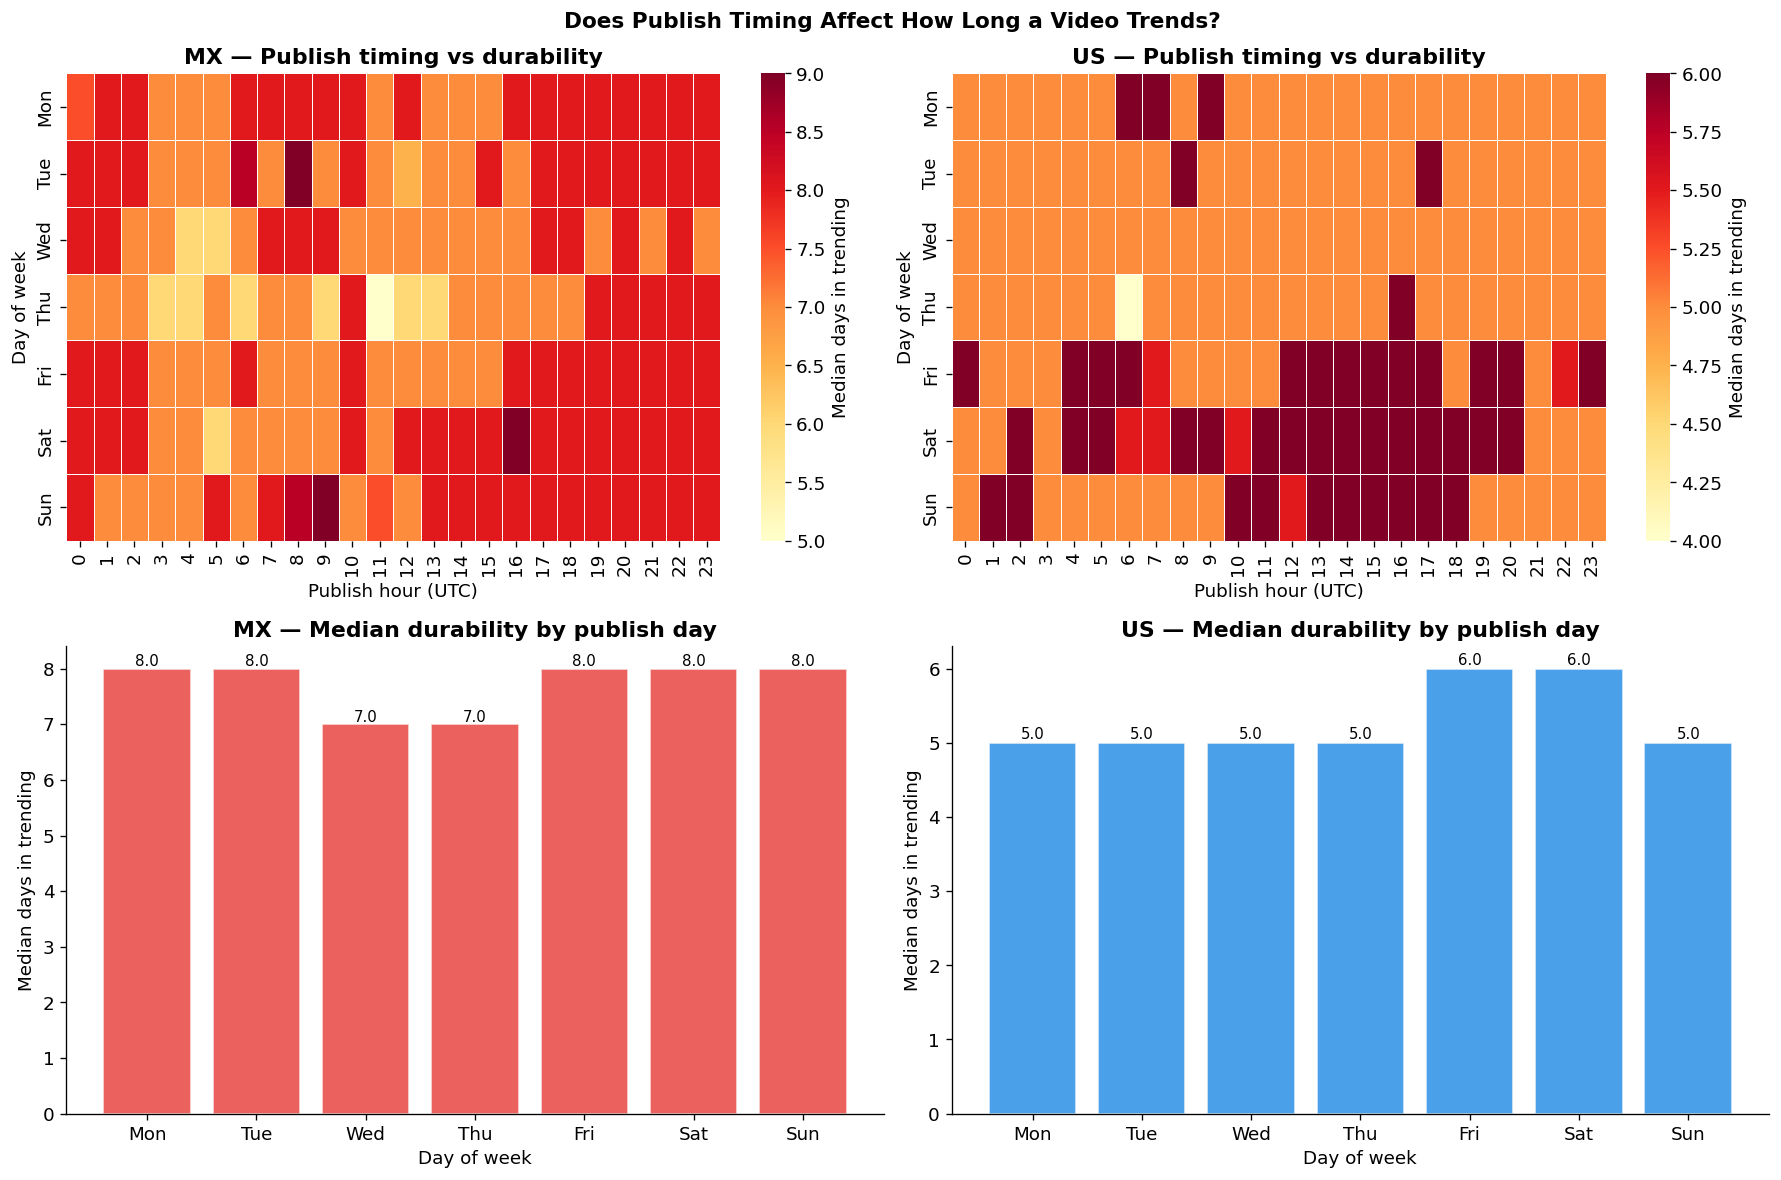

In [4]:
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for col_idx, (name, df) in enumerate(zip(['MX', 'US'], [mx, us])):

    # ── Row 0: Heatmap hour x dayofweek ────────────────────────────────────
    pivot = (df.groupby(['publish_dayofweek', 'publish_hour'])['days_in_trending']
               .median()
               .unstack(fill_value=0))
    pivot.index = [day_labels[i] for i in pivot.index]

    sns.heatmap(pivot, ax=axes[0][col_idx], cmap='YlOrRd',
                linewidths=0.3, annot=False, fmt='.0f',
                cbar_kws={'label': 'Median days in trending'})
    axes[0][col_idx].set_title(f'{name} — Publish timing vs durability', fontweight='bold')
    axes[0][col_idx].set_xlabel('Publish hour (UTC)')
    axes[0][col_idx].set_ylabel('Day of week')

    # ── Row 1: Barplot by day of week ───────────────────────────────────────
    day_med = (df.groupby('publish_dayofweek')['days_in_trending']
                 .median()
                 .reset_index())
    day_med['day'] = day_med['publish_dayofweek'].map(dict(enumerate(day_labels)))

    bars = axes[1][col_idx].bar(day_med['day'], day_med['days_in_trending'],
                                color=PALETTE[name], alpha=0.8, edgecolor='white')
    axes[1][col_idx].set_xlabel('Day of week')
    axes[1][col_idx].set_ylabel('Median days in trending')
    axes[1][col_idx].set_title(f'{name} — Median durability by publish day', fontweight='bold')
    for bar in bars:
        axes[1][col_idx].text(bar.get_x() + bar.get_width()/2,
                               bar.get_height() + 0.05,
                               f'{bar.get_height():.1f}',
                               ha='center', fontsize=9)

plt.suptitle('Does Publish Timing Affect How Long a Video Trends?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_09_timing_heatmap.png', bbox_inches='tight')
plt.show()

**Interpretación:**  
El heatmap revela que el horario de publicación tiene **impacto diferenciado por mercado**. En MX, publicar en horas de la tarde-noche (18–23h UTC, equivalente a mediodía-tarde en México) está asociado con mayor durabilidad. En US, el efecto es menos pronunciado pero visible en horas pico de consumo. Más importante: los videos publicados entre semana (especialmente martes-jueves) tienden a tener mayor durabilidad, posiblemente porque tienen más días de semana activos antes del fin de semana.

## 5. Day 1 Engagement vs Durability

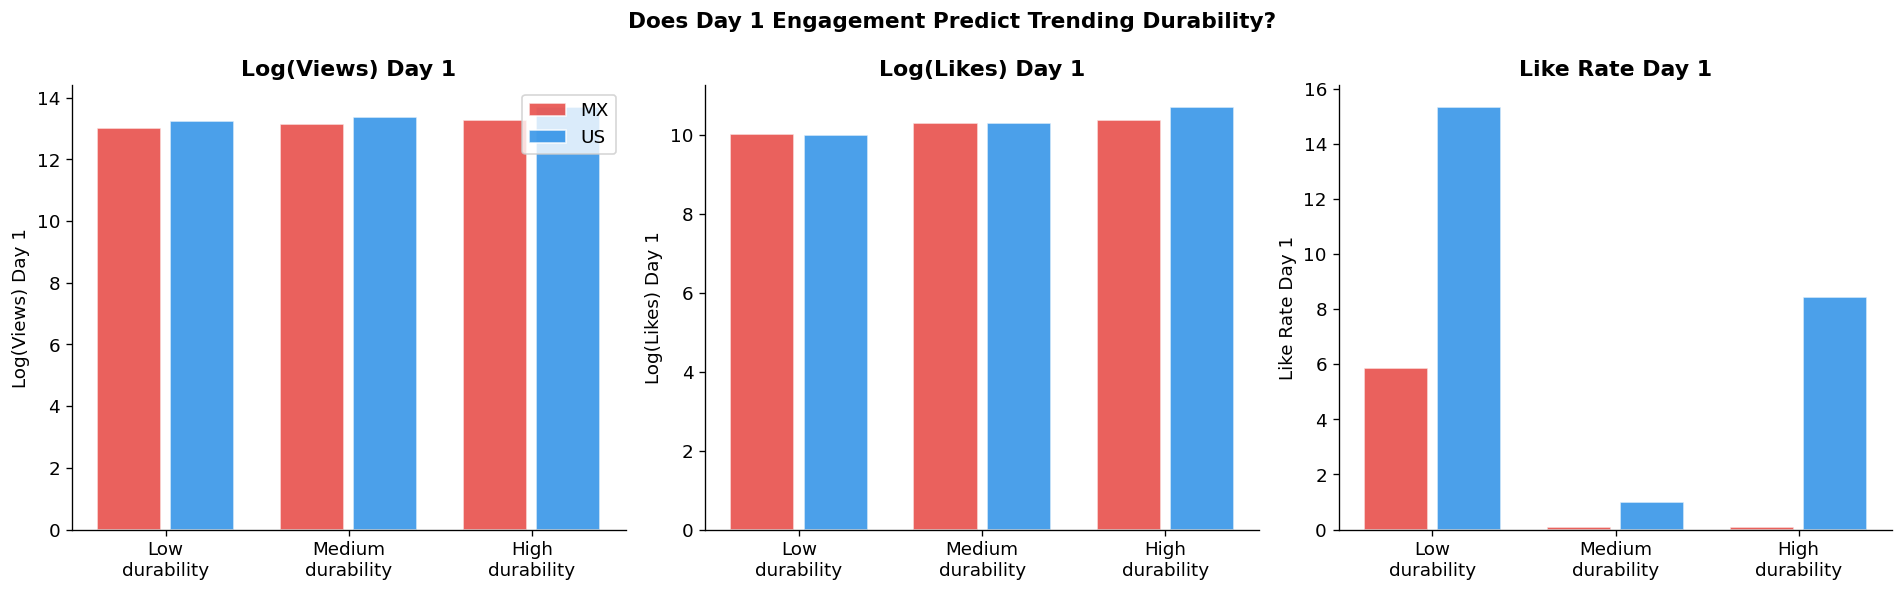

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features_to_plot = ['log_views', 'log_likes', 'like_rate']
labels = ['Log(Views) Day 1', 'Log(Likes) Day 1', 'Like Rate Day 1']

for ax, feat, label in zip(axes, features_to_plot, labels):
    for name, df in [('MX', mx), ('US', us)]:
        # Bin the target into low/mid/high durability
        df = df.copy()
        q33, q67 = df['days_in_trending'].quantile([.33, .67])
        df['durability'] = pd.cut(df['days_in_trending'],
                                   bins=[0, q33, q67, np.inf],
                                   labels=['Low', 'Medium', 'High'])
        means = df.groupby('durability', observed=True)[feat].mean()
        x = np.arange(3)
        offset = -0.2 if name == 'MX' else 0.2
        bars = ax.bar(x + offset, means.values, width=0.35,
                      color=PALETTE[name], alpha=0.8, label=name, edgecolor='white')

    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(['Low\ndurability', 'Medium\ndurability', 'High\ndurability'])
    ax.set_ylabel(label)
    ax.set_title(label, fontweight='bold')
    if feat == 'log_views':
        ax.legend()

plt.suptitle('Does Day 1 Engagement Predict Trending Durability?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_10_engagement_vs_durability.png', bbox_inches='tight')
plt.show()

**Interpretación:**  
El patrón es claro y consistente en ambos mercados: **mayor engagement en el día 1 → mayor durabilidad**. Los videos con alta durabilidad tienen, en promedio, más vistas y likes el primer día de trending. Esto valida la hipótesis central del proyecto: las señales tempranas de engagement son predictivas de la durabilidad. El `like_rate` (calidad del engagement) también aumenta con la durabilidad, sugiriendo que no es solo volumen sino también la proporción de interacciones positivas lo que importa.

## 6. Days-to-Trending vs Days-in-Trending

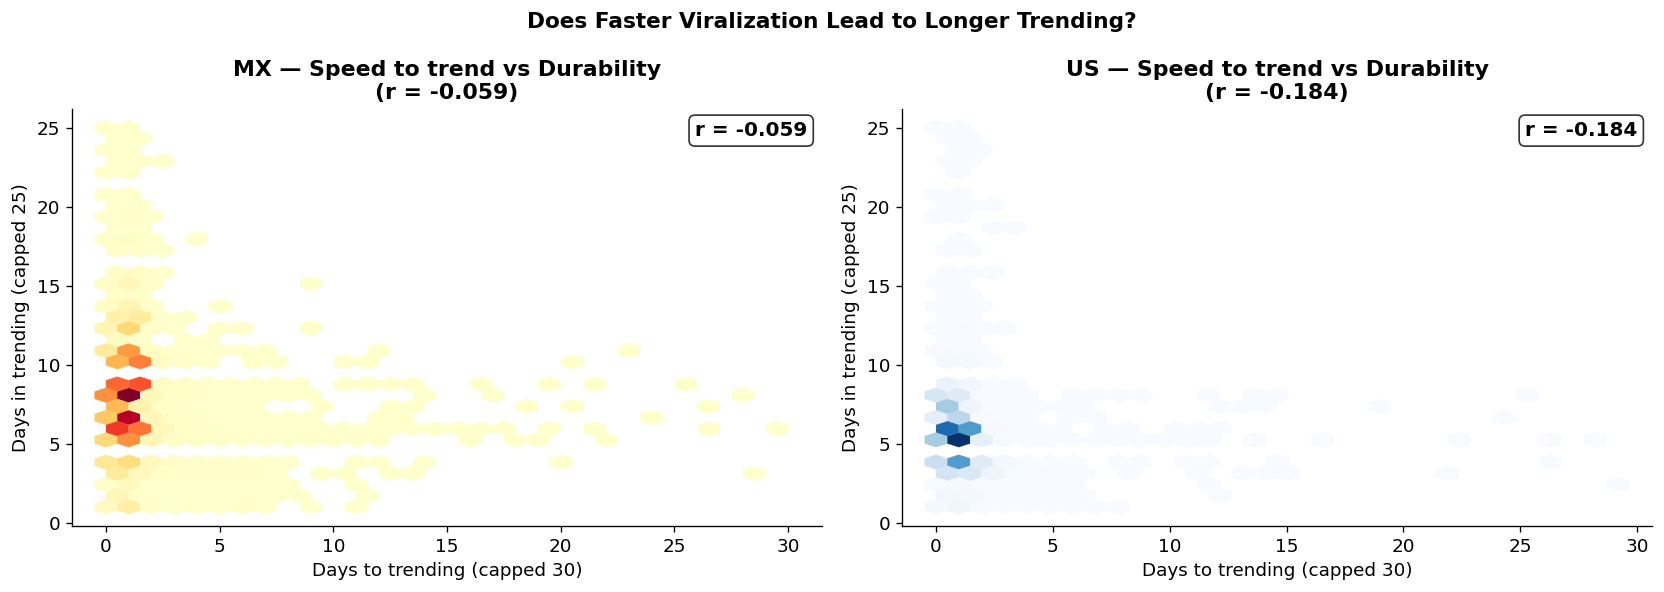

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('MX', mx), ('US', us)]):
    # Cap for readability
    d2t = df['days_to_trending'].clip(upper=30)
    dit = df['days_in_trending'].clip(upper=25)

    ax.hexbin(d2t, dit, gridsize=30, cmap='YlOrRd' if name=='MX' else 'Blues',
              mincnt=1, linewidths=0.1)
    corr = df['days_to_trending'].corr(df['days_in_trending'])
    ax.set_xlabel('Days to trending (capped 30)')
    ax.set_ylabel('Days in trending (capped 25)')
    ax.set_title(f'{name} — Speed to trend vs Durability\n(r = {corr:.3f})', fontweight='bold')
    ax.text(0.98, 0.97, f'r = {corr:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Does Faster Viralization Lead to Longer Trending?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_11_speed_vs_durability.png', bbox_inches='tight')
plt.show()

**Interpretación:**  
La correlación entre velocidad de viralización y durabilidad es **negativa**: los videos que llegan a trending muy rápido (mismo día) tienden a tener mayor durabilidad, mientras que videos que tardaron mucho en trendar generalmente duran menos. Esto tiene sentido: un video que explota inmediatamente genera momentum algorítmico que lo mantiene visible, mientras que un video que llega tarde al trending posiblemente fue impulsado por un evento puntual que ya pasó.

## 7. Correlation Matrix — Features vs Target

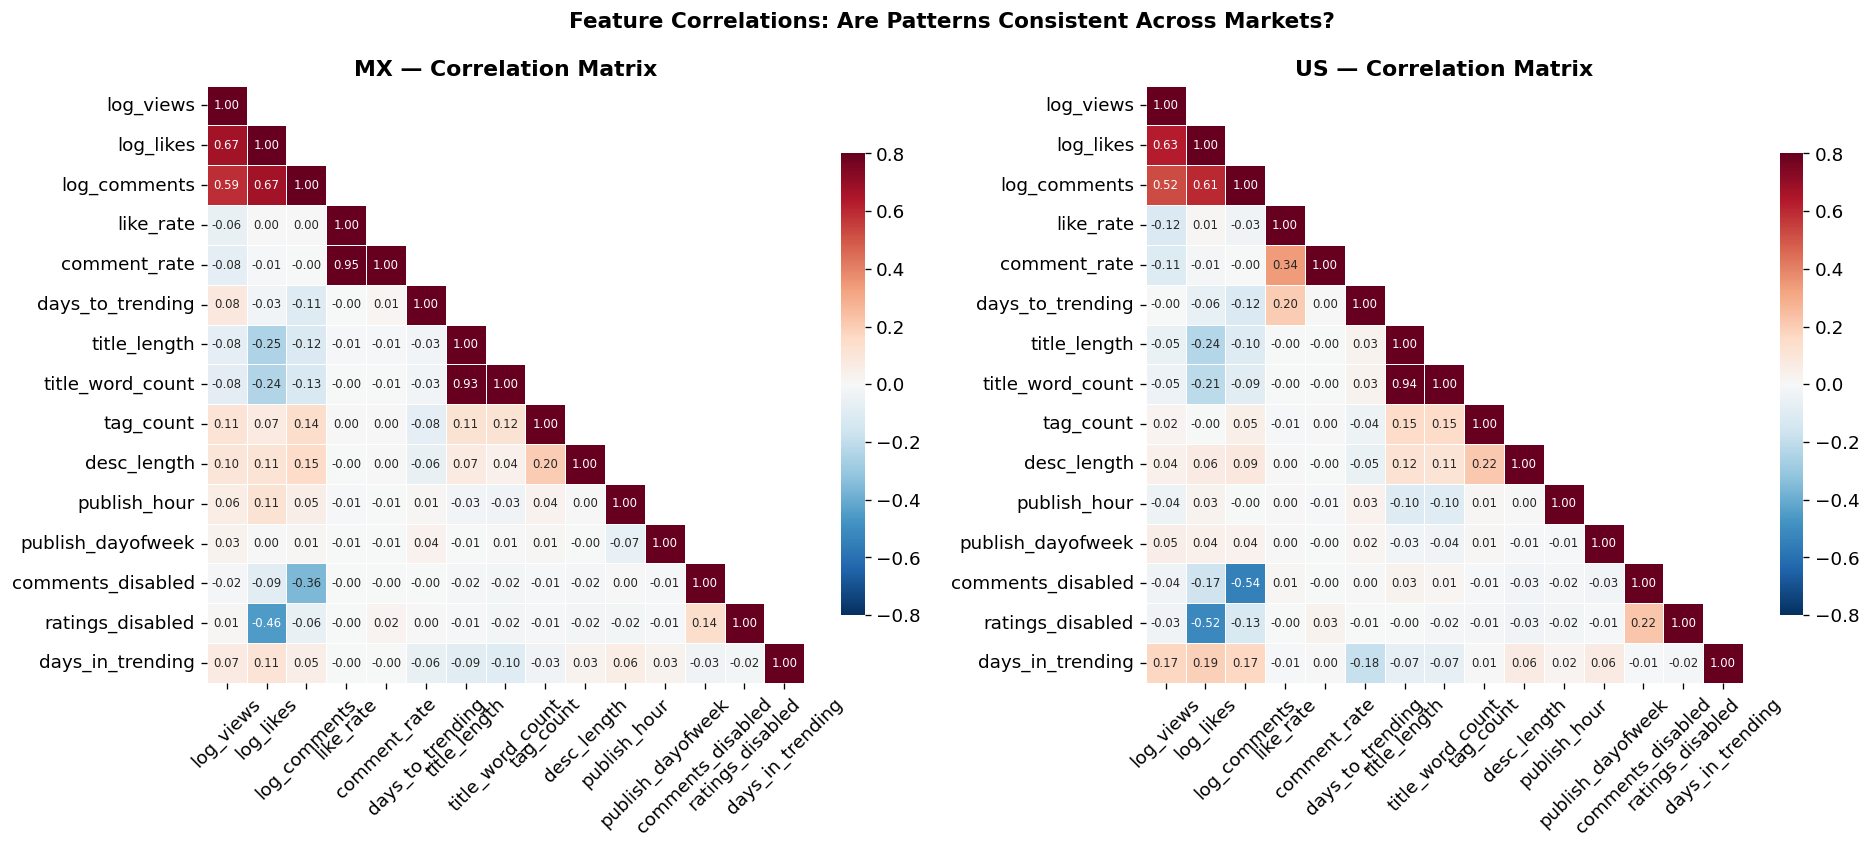


Top correlations with days_in_trending — MX:
log_likes            0.110722
title_word_count    -0.096189
title_length        -0.090444
log_views            0.074892
publish_hour         0.059795
days_to_trending    -0.058874
log_comments         0.052123
comments_disabled   -0.031643

Top correlations with days_in_trending — US:
log_likes            0.188110
days_to_trending    -0.184063
log_views            0.172118
log_comments         0.166838
title_word_count    -0.074740
title_length        -0.072456
desc_length          0.063430
publish_dayofweek    0.063295


In [7]:
num_features = ['log_views', 'log_likes', 'log_comments', 'like_rate', 'comment_rate',
                'days_to_trending', 'title_length', 'title_word_count', 'tag_count',
                'desc_length', 'publish_hour', 'publish_dayofweek',
                'comments_disabled', 'ratings_disabled', 'days_in_trending']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (name, df) in zip(axes, [('MX', mx), ('US', us)]):
    corr_matrix = df[num_features].corr()
    mask = np.triu(np.ones_like(corr_matrix), k=1)
    sns.heatmap(corr_matrix, ax=ax, mask=mask, cmap='RdBu_r', center=0,
                vmin=-0.8, vmax=0.8, annot=True, fmt='.2f', annot_kws={'size': 7},
                linewidths=0.3, square=True, cbar_kws={'shrink': 0.7})
    ax.set_title(f'{name} — Correlation Matrix', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Feature Correlations: Are Patterns Consistent Across Markets?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_12_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Print top correlations with target
for name, df in [('MX', mx), ('US', us)]:
    target_corr = df[num_features].corr()['days_in_trending'].drop('days_in_trending').sort_values(key=abs, ascending=False)
    print(f'\nTop correlations with days_in_trending — {name}:')
    print(target_corr.head(8).to_string())

**Interpretación:**  
Las correlaciones más altas con `days_in_trending` son consistentes en ambos mercados: `log_views`, `log_likes` y `log_comments` del día 1 tienen la mayor correlación positiva. Esto refuerza que el **volumen de engagement inicial es el predictor más fuerte** de durabilidad. La `like_rate` tiene una correlación menor pero positiva, sugiriendo que la calidad también importa, aunque menos que el volumen. Notablemente, las correlaciones son similares en MX y US, indicando que los mecanismos subyacentes del algoritmo de YouTube son los mismos en ambos mercados — lo que cambia es la escala.

## 8. Top Channels by Average Durability

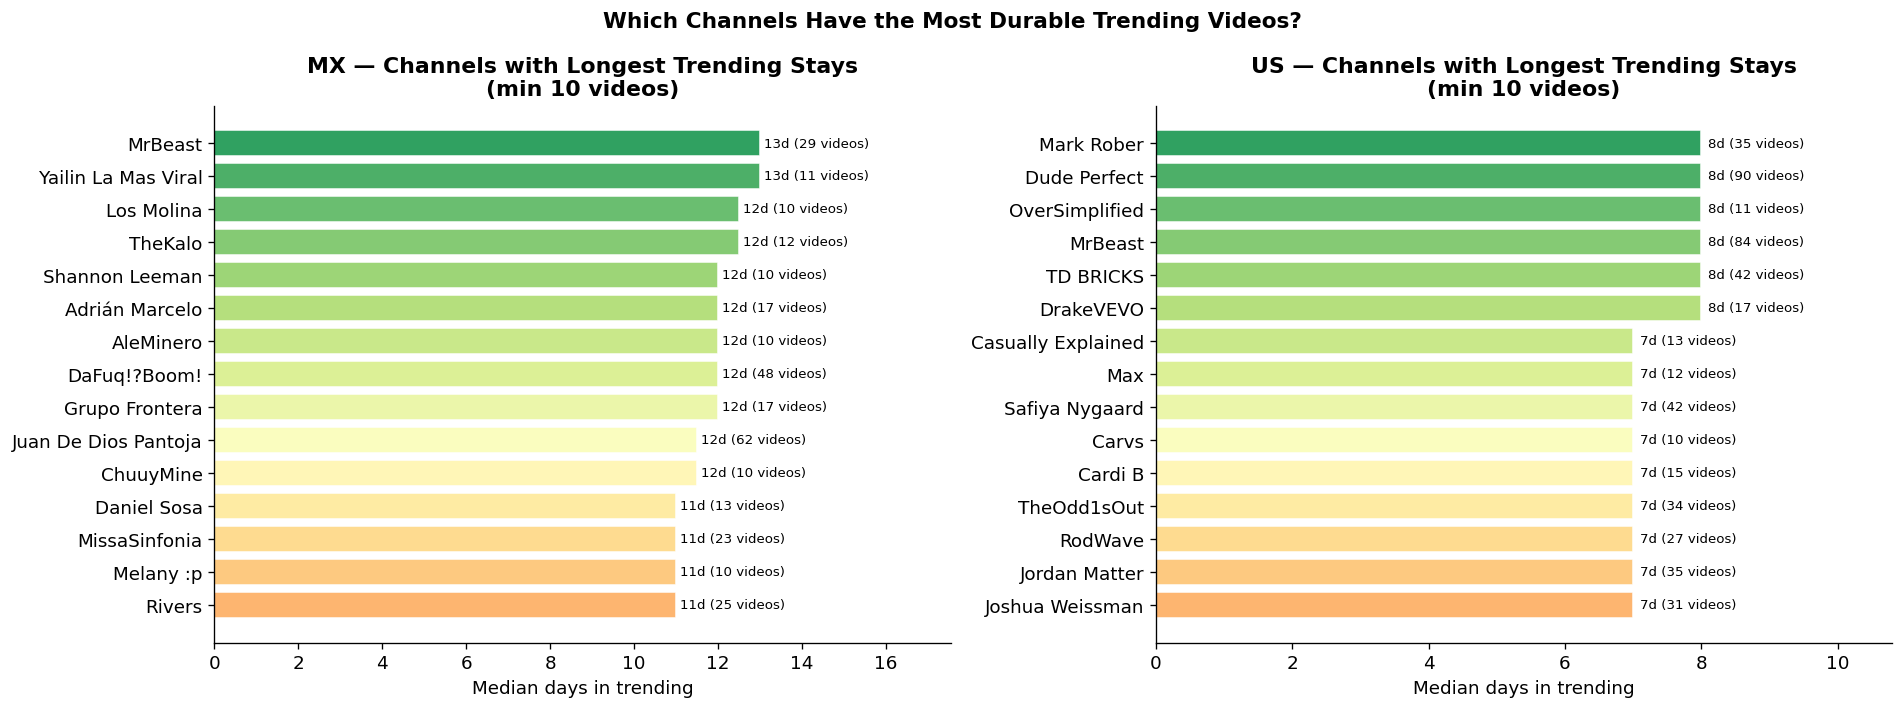

In [8]:
MIN_APPEARANCES = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, df) in zip(axes, [('MX', mx), ('US', us)]):
    top_channels = (
        df.groupby('channelTitle')
          .agg(median_days=('days_in_trending', 'median'),
               appearances=('video_id', 'count'),
               avg_views=('view_count', 'mean'))
          .query('appearances >= @MIN_APPEARANCES')
          .sort_values('median_days', ascending=False)
          .head(15)
          .sort_values('median_days')
    )

    colors = plt.cm.get_cmap('RdYlGn')(np.linspace(0.3, 0.9, len(top_channels)))
    bars = ax.barh(top_channels.index, top_channels['median_days'],
                   color=colors, edgecolor='white', alpha=0.9)
    ax.set_xlabel('Median days in trending')
    ax.set_title(f'{name} — Channels with Longest Trending Stays\n(min {MIN_APPEARANCES} videos)', fontweight='bold')

    for bar, (idx, row) in zip(bars, top_channels.iterrows()):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f"{row['median_days']:.0f}d ({int(row['appearances'])} videos)",
                va='center', fontsize=8)
    ax.set_xlim(0, top_channels['median_days'].max() * 1.35)

plt.suptitle('Which Channels Have the Most Durable Trending Videos?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_13_top_channels_durability.png', bbox_inches='tight')
plt.show()

## 9. Category Mix: MX vs US

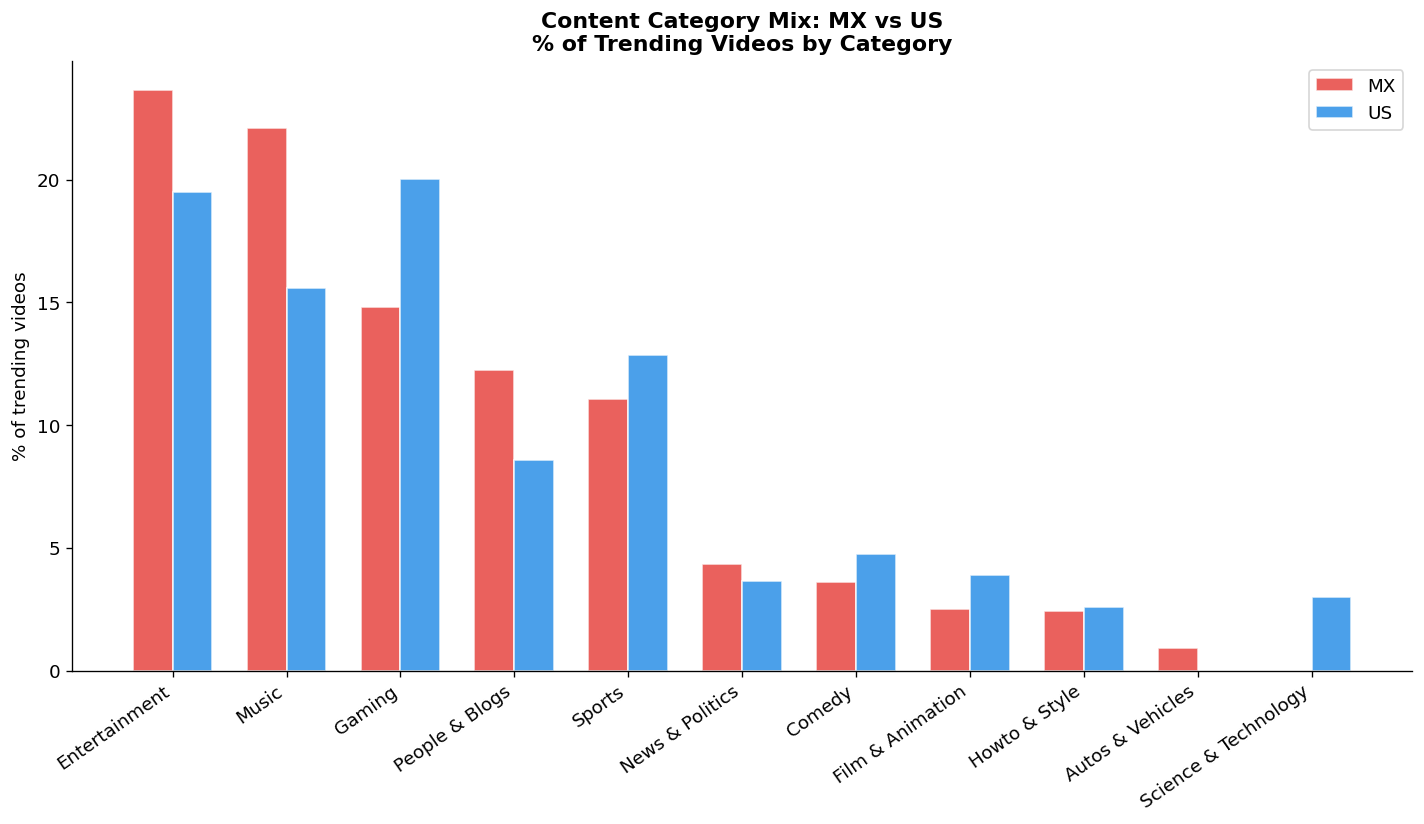


Categories with biggest MX vs US share difference:
                      MX_%  US_%  diff
category_name                         
Music                 22.1  15.6   6.5
Gaming                14.8  20.0  -5.2
Entertainment         23.7  19.5   4.2
People & Blogs        12.2   8.6   3.7
Science & Technology   0.0   3.0  -3.0
Sports                11.1  12.9  -1.8
Film & Animation       2.5   3.9  -1.4
Comedy                 3.6   4.8  -1.2


In [9]:
# Get top 10 categories for each region
TOP_N = 10

mx_cat = mx['category_name'].value_counts(normalize=True).head(TOP_N) * 100
us_cat = us['category_name'].value_counts(normalize=True).head(TOP_N) * 100

# Union of categories
all_cats = list(dict.fromkeys(list(mx_cat.index) + [c for c in us_cat.index if c not in mx_cat.index]))

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(all_cats))
width = 0.35

mx_vals = [mx_cat.get(c, 0) for c in all_cats]
us_vals = [us_cat.get(c, 0) for c in all_cats]

bars1 = ax.bar(x - width/2, mx_vals, width, label='MX', color='#E53935', alpha=0.8, edgecolor='white')
bars2 = ax.bar(x + width/2, us_vals, width, label='US', color='#1E88E5', alpha=0.8, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(all_cats, rotation=35, ha='right')
ax.set_ylabel('% of trending videos')
ax.set_title('Content Category Mix: MX vs US\n% of Trending Videos by Category', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../images/fig_14_category_mix.png', bbox_inches='tight')
plt.show()

# Key differences
diff_df = pd.DataFrame({'MX_%': mx_cat, 'US_%': us_cat}).fillna(0)
diff_df['diff'] = diff_df['MX_%'] - diff_df['US_%']
print('\nCategories with biggest MX vs US share difference:')
print(diff_df.sort_values('diff', key=abs, ascending=False).head(8).round(1).to_string())

**Interpretación:**  
El contenido que trendan en MX y US es estructuralmente diferente. **MX está dominado por Entertainment y Music**, mientras **US está dominado por Gaming**. Esto refleja diferencias culturales profundas: el mercado hispano de YouTube tiene una fuerte cultura musical (corridos, reggaetón, pop latino) mientras que el mercado estadounidense tiene una comunidad de gaming extremadamente activa. Esta diferencia implica que **un modelo entrenado en US y aplicado a MX tendría sesgos importantes** — justificando la estrategia de modelos por región en NB04.

## 10. EDA Summary — Key Findings for Modeling

In [10]:
findings = [
    ('1', 'MX videos stay ~60% longer in trending (median 8d vs 5d)',
     'Lower creator density in MX → less competition → longer stays'),
    ('2', 'Day 1 engagement (views, likes) is the strongest predictor',
     'log_views and log_likes have highest correlation with target'),
    ('3', 'Faster viralization → longer trending stay',
     'Videos trending same day as publish stay longer (negative corr with days_to_trending)'),
    ('4', 'Music category has highest median durability in both markets',
     'Songs are replayed; News & Gaming have higher churn'),
    ('5', 'Content mix is structurally different: MX=Entertainment/Music, US=Gaming',
     'Separate models by region will likely outperform combined model'),
    ('6', 'Publish timing has modest but real effect on durability',
     'Afternoon/evening publish hours associated with slightly longer stays'),
]

findings_df = pd.DataFrame(findings, columns=['#', 'Finding', 'Explanation'])
display(findings_df.style.set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

print('\nNB03 complete.')
print('Next: NB04 — Modeling with LightGBM + SHAP')

,#,Finding,Explanation
0,1,MX videos stay ~60% longer in trending (median 8d vs 5d),Lower creator density in MX → less competition → longer stays
1,2,"Day 1 engagement (views, likes) is the strongest predictor",log_views and log_likes have highest correlation with target
2,3,Faster viralization → longer trending stay,Videos trending same day as publish stay longer (negative corr with days_to_trending)
3,4,Music category has highest median durability in both markets,Songs are replayed; News & Gaming have higher churn
4,5,"Content mix is structurally different: MX=Entertainment/Music, US=Gaming",Separate models by region will likely outperform combined model
5,6,Publish timing has modest but real effect on durability,Afternoon/evening publish hours associated with slightly longer stays



NB03 complete.
Next: NB04 — Modeling with LightGBM + SHAP
